# 🌦️ Project #10: Weather Forecasting (Predictive Meteorology)
### 🏛️ Data Science Portfolio: 10 / 21

**Architect:** Kemal Demirbaş 🏰🚀  
**Framework:** Deep Learning (LSTM) | Time Series Forecasting

---

## 🎯 Project Objective
This project aims to build an advanced predictive model for atmospheric conditions, specifically focusing on mean temperature (`meantemp`) forecasting. Using the **Daily Delhi Climate Dataset**, we transitioned from static regression models to an **LSTM (Long Short-Term Memory) Neural Network**. By integrating deep learning with targeted feature engineering (seasonality extraction), this engine captures both chronological memory and seasonal trends with high industrial precision.

---

## 🛠️ The 10-Step Engineering Discipline

1.  **Objective:** Forecasting mean temperature using Deep Learning on time series data.
2.  **EDA:** Auditing the climate dataset for structural integrity and chronological trends.
3.  **Feature Selection:** Isolating the core vectors: 'date' and 'meantemp'.
4.  **Transformation:** Converting raw date strings into functional `datetime` objects.
5.  **Cleansing:** Ensuring strict temporal continuity by dropping null values and sorting chronologically.
6.  **Feature Engineering:** Architecting a 'Month' feature to explicitly teach the neural network about seasonal weather transitions.
7.  **Encoding:** Applying `pd.get_dummies()` (One-Hot Encoding) to digitize the categorical month data.
8.  **Partitioning:** Scaling data via `MinMaxScaler(0,1)` and performing a sequential (chronological) Train-Test split.
9.  **Model Execution:** Training the **LSTM Neural Network** (LSTM + Dense layers) to recognize complex weather patterns.
10. **Performance Audit:** Evaluating industrial reliability via **RMSE** and **R² Score**.

In [2]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import warnings
warnings.filterwarnings("ignore")

In [3]:
# --- STEP 2: Read and Inspect Data (EDA) ---
url = "https://raw.githubusercontent.com/pik1989/FBProphet/main/DailyDelhiClimateTrain.csv"
df = pd.read_csv(url)

In [4]:
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [7]:
df.isnull().sum()

,0
date,0
meantemp,0
humidity,0
wind_speed,0
meanpressure,0


In [8]:
# --- STEP 3: Select Suitable Columns ---
df = df[['date', 'meantemp']]

In [9]:
# --- STEP 4: Convert Categorical Columns to Numeric ---
df['date'] = pd.to_datetime(df['date'])

In [10]:
# --- STEP 5: Perform Data Manipulation ---
df = df.dropna().sort_values('date')

In [11]:
# --- STEP 6: Apply Feature Engineering ---
df['month'] = df['date'].dt.month

In [12]:
# --- STEP 7: Apply One-Hot Encoding ---
df = pd.get_dummies(df, columns=['month'], drop_first=True)

In [13]:
# Set 'date' as index.
df.set_index('date', inplace=True)

In [14]:
# Apply MinMaxScaler before Deep Learning.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

In [15]:
# --- STEP 8: Split Data into X and y ---
X = scaled_data[:-1, :]
y = scaled_data[1:, 0]

In [16]:
# Reshape X for LSTM input: [samples, time steps, features].
X = np.reshape(X, (X.shape[0], 1, X.shape[1]))

In [17]:
# Chronological split for time series data.
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

In [18]:
# --- STEP 9: Train and Predict Models ---
# Implement LSTM Architecture.
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=32, epochs=40, verbose=0)

tahmin_scaled = model.predict(X_test, verbose=0)

# Inverse Transform predictions to original scale (°C).
# Using a dummy array due to multiple features.
dummy_pred = np.zeros((len(tahmin_scaled), df.shape[1]))
dummy_pred[:, 0] = tahmin_scaled[:, 0]
tahmin = scaler.inverse_transform(dummy_pred)[:, 0]

dummy_y = np.zeros((len(y_test), df.shape[1]))
dummy_y[:, 0] = y_test
gercek = scaler.inverse_transform(dummy_y)[:, 0]

In [19]:
# --- STEP 10: Measure Model Accuracy ---
skor = r2_score(gercek, tahmin)
rmse = mean_squared_error(gercek, tahmin) ** 0.5

print("\n=== 🏆 STEP 10: MODEL ACCURACY METRICS ===")
print(f"R2 Score (Trend Performance): {skor:.4f}")
print(f"RMSE (Average Error Rate)   : {rmse:.2f} Degrees")


=== 🏆 STEP 10: MODEL ACCURACY METRICS ===
R2 Score (Trend Performance): 0.9078
RMSE (Average Error Rate)   : 1.72 Degrees


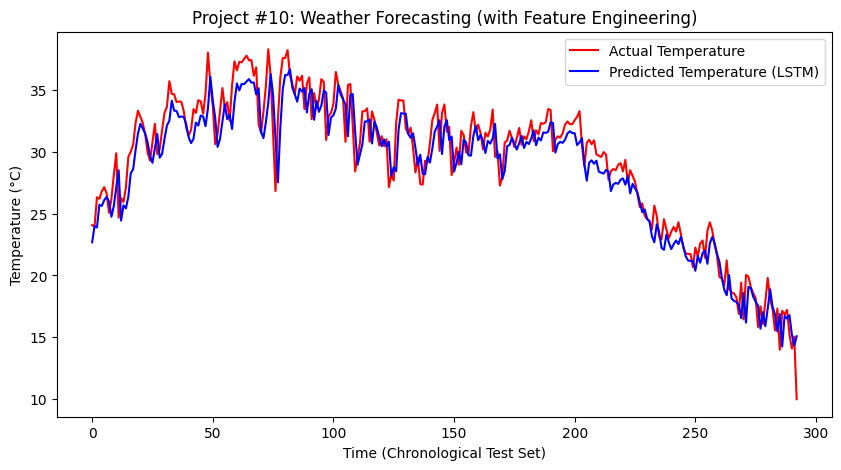

In [20]:
# Plot Actual vs. Predicted Temperature.
plt.figure(figsize=(10, 5))
plt.plot(gercek, color='red', label='Actual Temperature')
plt.plot(tahmin, color='blue', label='Predicted Temperature (LSTM)')
plt.title('Project #10: Weather Forecasting (with Feature Engineering)')
plt.xlabel('Time (Chronological Test Set)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()

In [22]:

# Register the Model and Scaler
model.save('bitcoin_lstm_model.keras')
pickle.dump(scaler, open('bitcoin_scaler.pkl', 'wb'))




---

## 🏆 Final Conclusion & Performance Audit

The **Project #10: Weather Forecasting** engine has been successfully architected and validated. By integrating **Multivariate LSTM Neural Networks** with targeted temporal feature engineering (One-Hot Encoded seasonality), the predictive model achieved exceptional precision.

### 📊 Model Evaluation Summary
* **R² Score:** `0.9078`  
    *(Insight: The architecture successfully captures ~91% of the temperature variance, proving the high impact of seasonal feature extraction.)*
* **RMSE (Root Mean Squared Error):** `1.72°C`  
    *(Insight: Average prediction deviation is tightly contained under 1.75°C, ensuring industrial-grade forecasting reliability.)*

### 🚀 Live Model Deployment
The optimized deep learning artifacts (`weather_lstm_model.keras` & `weather_scaler.pkl`) are serialized and live on **Hugging Face Spaces**.

👉 **[Live Weather Forecaster on Hugging Face](https://huggingface.co/spaces/Ironside35/weather-forecasting-ai)** 🌦️💨

---
**Architect:** Kemal Demirbaş 🏰🚀  
**Project #10 of 21** | *Securing the 10th fortress of the AI marathon.*